In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("deliveries.csv")

In [6]:
df.columns = df.columns.str.strip().str.lower()
print("Columns:\n", df.columns)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values:\n", df.isnull().sum())

Columns:
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

First 5 rows:
   match_id  inning         batting_team                 bowling_team  over  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
3         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
4         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   

   ball    batsman non_striker    bowler  is_super_over  ...  bye_runs  \
0     1  DA Warner    S Dhawan  TS Mills              0  ...         0   
1     2

In [7]:
if 'player_dismissed' in df.columns:
    df['player_dismissed'] = df['player_dismissed'].fillna("Not Out")


Top 10 Scorers:
 batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64


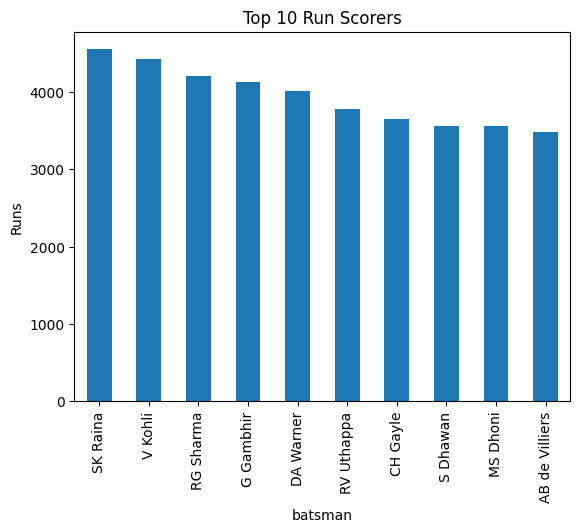

In [8]:
top_scorers = df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Scorers:\n", top_scorers)
top_scorers.plot(kind='bar')
plt.title("Top 10 Run Scorers")
plt.ylabel("Runs")
plt.show()


Top Strike Rates:
 batsman
DL Chahar        233.333333
Umar Gul         205.263158
RS Sodhi         200.000000
BCJ Cutting      177.142857
AJ Tye           176.666667
Shahid Afridi    176.086957
I Malhotra       175.000000
SN Khan          171.844660
CR Brathwaite    169.642857
LJ Wright        168.253968
dtype: float64


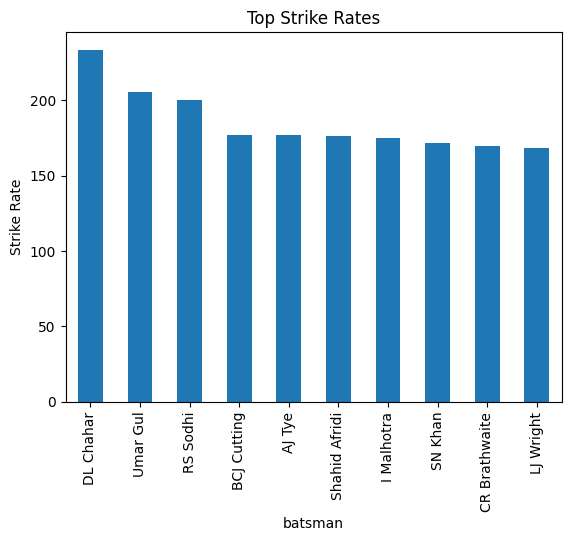

In [9]:
balls = df.groupby('batsman')['ball'].count()
runs = df.groupby('batsman')['batsman_runs'].sum()
strike_rate = (runs / balls) * 100
strike_rate = strike_rate.sort_values(ascending=False).head(10)
print("\nTop Strike Rates:\n", strike_rate)
strike_rate.plot(kind='bar')
plt.title("Top Strike Rates")
plt.ylabel("Strike Rate")
plt.show()


Team Runs:
 batting_team
Mumbai Indians                 24521
Royal Challengers Bangalore    23436
Kings XI Punjab                23068
Kolkata Knight Riders          21965
Delhi Daredevils               21953
Chennai Super Kings            20899
Rajasthan Royals               17703
Sunrisers Hyderabad            11652
Deccan Chargers                11463
Pune Warriors                   6358
Name: total_runs, dtype: int64


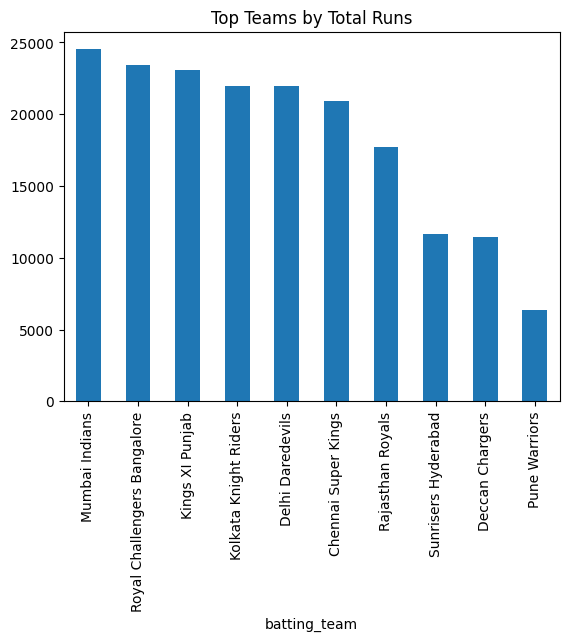

In [10]:
team_runs = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
print("\nTeam Runs:\n", team_runs.head(10))
team_runs.head(10).plot(kind='bar')
plt.title("Top Teams by Total Runs")
plt.show()


Top Bowlers:
 bowler
SL Malinga         170
A Mishra           142
DJ Bravo           137
Harbhajan Singh    136
PP Chawla          133
R Vinay Kumar      125
A Nehra            121
Z Khan             119
B Kumar            117
R Ashwin           110
Name: player_dismissed, dtype: int64


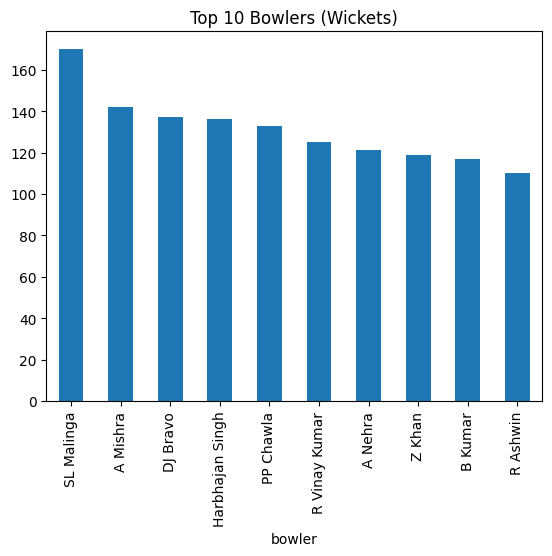

In [11]:
wickets = df[df['player_dismissed'] != "Not Out"]
top_bowlers = wickets.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10)
print("\nTop Bowlers:\n", top_bowlers)
top_bowlers.plot(kind='bar')
plt.title("Top 10 Bowlers (Wickets)")
plt.show()

In [17]:
fours = df[df['batsman_runs'] == 4].groupby('batsman')['batsman_runs'].count()
sixes = df[df['batsman_runs'] == 6].groupby('batsman')['batsman_runs'].count()
print("\nTop 5 Players with Most 4s:\n", fours.sort_values(ascending=False).head(5))
print("\nTop 5 Players with Most 6s:\n", sixes.sort_values(ascending=False).head(5))


Top 5 Players with Most 4s:
 batsman
G Gambhir    484
SK Raina     402
DA Warner    401
S Dhawan     401
V Kohli      384
Name: batsman_runs, dtype: int64

Top 5 Players with Most 6s:
 batsman
CH Gayle     266
SK Raina     174
RG Sharma    173
V Kohli      160
DA Warner    160
Name: batsman_runs, dtype: int64


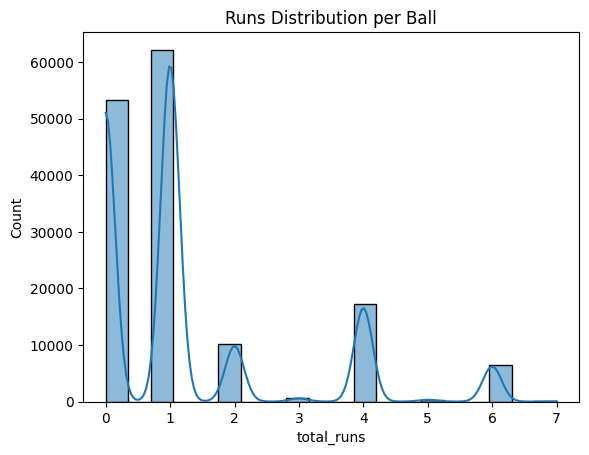

In [18]:
sns.histplot(df['total_runs'], bins=20, kde=True)
plt.title("Runs Distribution per Ball")
plt.show()